In [ ]:
import kagglehub
chethuhn_network_intrusion_dataset_path = kagglehub.dataset_download('chethuhn/network-intrusion-dataset')

print('Data source import complete.')


Part 2.2 - Synthetic Network Traffic with a Conditional WGAN-GP (CICIDS 2017)



Part 2.2 (CICIDS 2017)


In [ ]:
# If running on Colab, upload the CICIDS CSV(s) or mount Drive, then set DATA_DIR.
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import QuantileTransformer, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from scipy import stats

SEED = 7
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

DATA_DIR = "/kaggle/input/datasets/chethuhn/"                       # folder holding the CICIDS CSV files
WED_FILE = "network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv"

# --- consistent, clean plot styling for every figure in this notebook ---
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 11, "legend.fontsize": 9, "legend.framealpha": 0.9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
})


Device: cuda


1. Load and explore the Wednesday capture

In [ ]:
wed = load_cicids_csv(os.path.join(DATA_DIR, WED_FILE))
wed["target"] = wed["Label"].map(simplify_label)
wed_full = wed[wed["target"].isin(["BENIGN", "DoS"])].copy()
print("Full Wednesday class balance (the real, imbalanced distribution):")
print(wed_full["target"].value_counts())

Full Wednesday class balance (the real, imbalanced distribution):
target
BENIGN    439683
DoS       251723
Name: count, dtype: int64


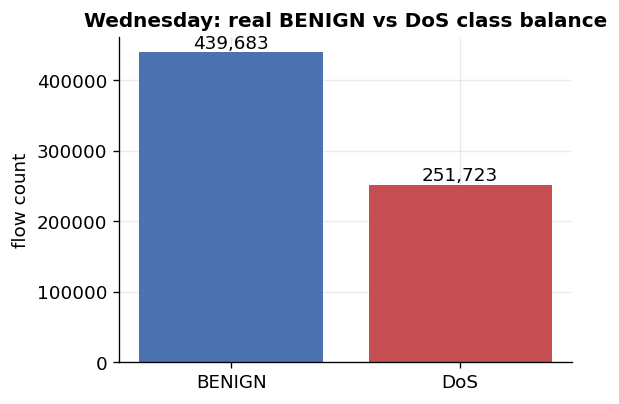

In [ ]:
# EDA — TRUE class balance of the Wednesday capture (note the strong imbalance).
vc = wed_full["target"].value_counts()
plt.figure(figsize=(5, 3.5))
plt.bar(vc.index, vc.values, color=["#4c72b0", "#c44e52"])
for i, v in enumerate(vc.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.ylabel("flow count")
plt.title("Wednesday: real BENIGN vs DoS class balance"); plt.tight_layout(); plt.show()

In [ ]:
# For tractable WGAN-GP training we use a BALANCED subsample of the (imbalanced) data above.
# This is a modelling choice for the generator, not a change to the reported class balance.
CAP_PER_CLASS = 20000
wed = (wed_full.groupby("target", group_keys=False)
              .apply(lambda g: g.sample(min(len(g), CAP_PER_CLASS), random_state=SEED))
              .reset_index(drop=True))
print("Balanced training subset:", len(wed), "rows |", dict(wed["target"].value_counts()))

Balanced training subset: 40000 rows | {'BENIGN': np.int64(20000), 'DoS': np.int64(20000)}


/tmp/ipykernel_58/2854682441.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), CAP_PER_CLASS), random_state=SEED))


2. Preprocessing

In [ ]:
def build_feature_matrix(df, label_col="target"):
    """Return X (quantile-normalised features), y (int labels), and helpers."""
    X_df = df.drop(columns=["Label", label_col]).select_dtypes(include=[np.number])
    X_df = X_df.loc[:, X_df.var() > 1e-8]                 # drop constant columns
    feature_names = X_df.columns.tolist()

    qt = QuantileTransformer(output_distribution="normal",
                             n_quantiles=min(1000, len(X_df)), random_state=SEED)
    X = qt.fit_transform(X_df.values.astype(np.float32)).astype(np.float32)

    le = LabelEncoder()
    y = le.fit_transform(df[label_col].values)            # BENIGN->0, DoS->1
    return X, y, feature_names, qt, le

X, y, FEATURES, qt, le = build_feature_matrix(wed)
FEAT_DIM = X.shape[1]
N_CLASSES = len(le.classes_)
print(f"Feature dim: {FEAT_DIM} | classes: {list(le.classes_)} | samples: {len(X)}")

Feature dim: 68 | classes: ['BENIGN', 'DoS'] | samples: 40000


3. Conditional WGAN-GP

In [ ]:
class CondGen(nn.Module):
    def __init__(self, z_dim, feat_dim, n_cls, emb=16):
        super().__init__()
        self.emb = nn.Embedding(n_cls, emb)
        self.net = nn.Sequential(
            nn.Linear(z_dim + emb, 128), nn.BatchNorm1d(128), nn.LeakyReLU(0.2),
            nn.Linear(128, 256),         nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, feat_dim))
    def forward(self, z, y):
        return self.net(torch.cat([z, self.emb(y)], dim=1))

class CondCritic(nn.Module):
    def __init__(self, feat_dim, n_cls, emb=16):
        super().__init__()
        self.emb = nn.Embedding(n_cls, emb)
        self.net = nn.Sequential(
            nn.Linear(feat_dim + emb, 256), nn.LayerNorm(256), nn.LeakyReLU(0.2),
            nn.Linear(256, 128),            nn.LayerNorm(128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1))            # real-valued score, no sigmoid
    def forward(self, x, y):
        return self.net(torch.cat([x, self.emb(y)], dim=1))

In [ ]:
def gradient_penalty(critic, real, fake, labels):
    """WGAN-GP penalty: ||grad_critic(x_hat)||_2 should be 1 along real<->fake lines."""
    bs = real.size(0)
    eps = torch.rand(bs, 1, device=real.device)
    x_hat = (eps * real + (1 - eps) * fake).requires_grad_(True)
    score = critic(x_hat, labels)
    grads = torch.autograd.grad(outputs=score, inputs=x_hat,
                                grad_outputs=torch.ones_like(score),
                                create_graph=True, retain_graph=True)[0]
    return ((grads.norm(2, dim=1) - 1) ** 2).mean()


def train_cwgan_gp(X, y, z_dim=32, epochs=80, batch=256,
                   n_critic=3, gp_weight=10.0, lr=1e-4):
    """Train a class-conditional WGAN-GP on tabular features; returns generator, critic and loss history."""
    feat_dim, n_cls = X.shape[1], len(np.unique(y))
    G = CondGen(z_dim, feat_dim, n_cls).to(DEVICE)
    C = CondCritic(feat_dim, n_cls).to(DEVICE)
    opt_g = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.9))
    opt_c = torch.optim.Adam(C.parameters(), lr=lr, betas=(0.5, 0.9))

    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(Xt, yt),
        batch_size=batch, shuffle=True, drop_last=True)

    c_hist, g_hist = [], []
    for ep in range(1, epochs + 1):
        c_run = g_run = c_steps = g_steps = 0
        for real, lbl in loader:
            real, lbl = real.to(DEVICE), lbl.to(DEVICE); bs = real.size(0)

            # ---- critic: maximise E[C(real)] - E[C(fake)] - gp ----
            z = torch.randn(bs, z_dim, device=DEVICE)
            fake = G(z, lbl).detach()
            gp = gradient_penalty(C, real, fake, lbl)
            c_loss = C(fake, lbl).mean() - C(real, lbl).mean() + gp_weight * gp
            opt_c.zero_grad(); c_loss.backward(); opt_c.step()
            c_run += c_loss.item(); c_steps += 1

            # ---- generator every n_critic critic steps ----
            if c_steps % n_critic == 0:
                z = torch.randn(bs, z_dim, device=DEVICE)
                g_loss = -C(G(z, lbl), lbl).mean()
                opt_g.zero_grad(); g_loss.backward(); opt_g.step()
                g_run += g_loss.item(); g_steps += 1

        c_hist.append(c_run / max(c_steps, 1)); g_hist.append(g_run / max(g_steps, 1))
        if ep % 20 == 0 or ep == epochs:
            print(f"epoch {ep:3d} | critic {c_hist[-1]:.3f} | gen {g_hist[-1]:.3f}")
    return G, C, c_hist, g_hist, z_dim

epoch  20 | critic -10.964 | gen 8.633
epoch  40 | critic -10.081 | gen 7.102
epoch  60 | critic -9.357 | gen 7.871
epoch  80 | critic -8.623 | gen 8.673


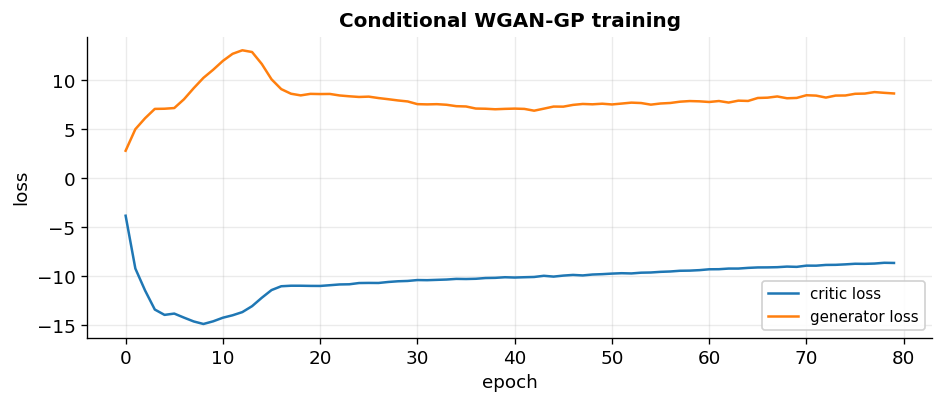

In [ ]:
G, C, c_hist, g_hist, Z_DIM = train_cwgan_gp(X, y, epochs=80)

plt.figure(figsize=(8, 3.5))
plt.plot(c_hist, label="critic loss"); plt.plot(g_hist, label="generator loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Conditional WGAN-GP training"); plt.legend()
plt.tight_layout(); plt.show()

In [ ]:
@torch.no_grad()
def synthesize(G, z_dim, label_int, n):
    """Generate n synthetic feature vectors for a given class label."""
    G.eval()
    z = torch.randn(n, z_dim, device=DEVICE)
    y = torch.full((n,), label_int, dtype=torch.long, device=DEVICE)
    out = G(z, y).cpu().numpy()
    G.train()
    return out

# Separate real/synthetic pools per class for evaluation.
EVAL_N = 1500
real_by_cls = {c: X[y == i][:EVAL_N] for i, c in enumerate(le.classes_)}
fake_by_cls = {c: synthesize(G, Z_DIM, i, EVAL_N) for i, c in enumerate(le.classes_)}

4. PCA and t-SNE - do real and synthetic flows overlap?

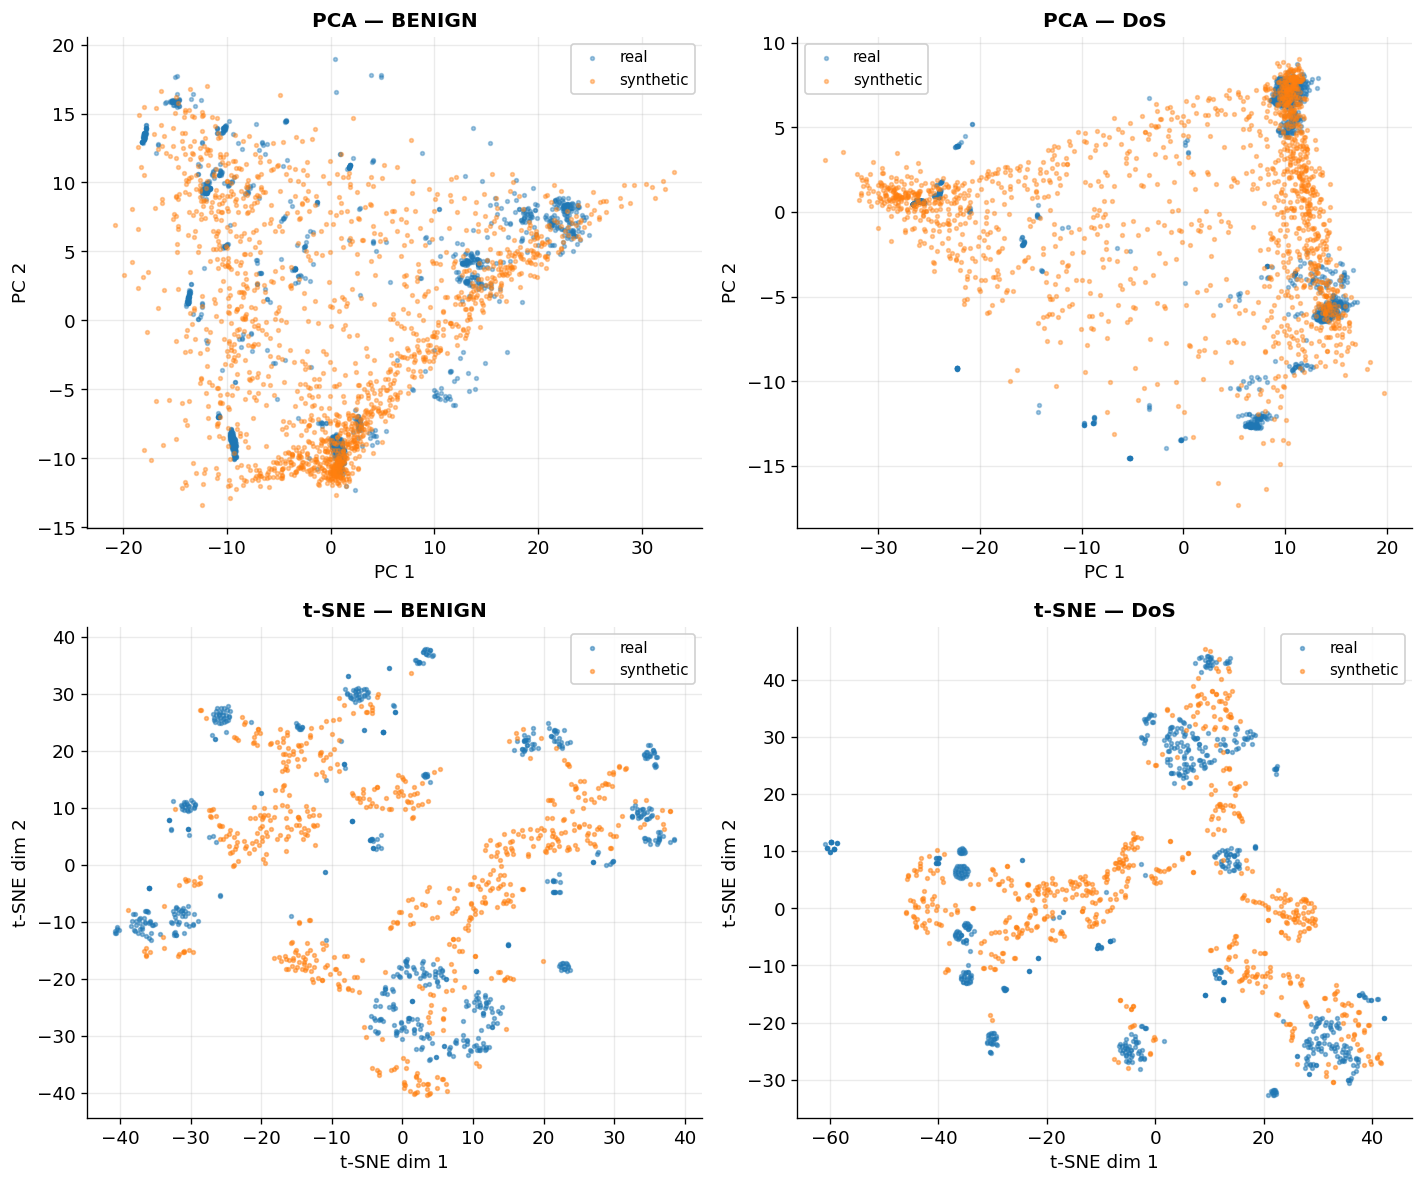

In [ ]:
fig, axes = plt.subplots(2, N_CLASSES, figsize=(6 * N_CLASSES, 10))
for col, cls in enumerate(le.classes_):
    real_c, fake_c = real_by_cls[cls], fake_by_cls[cls]

    # PCA fitted on the real class, both sets projected into it.
    pca = PCA(n_components=2, random_state=SEED).fit(real_c)
    rp, fp = pca.transform(real_c), pca.transform(fake_c)
    axes[0, col].scatter(rp[:, 0], rp[:, 1], s=5, alpha=.4, label="real")
    axes[0, col].scatter(fp[:, 0], fp[:, 1], s=5, alpha=.4, label="synthetic")
    axes[0, col].set_title(f"PCA — {cls}"); axes[0, col].set_xlabel("PC 1"); axes[0, col].set_ylabel("PC 2"); axes[0, col].legend()

    # t-SNE on the stacked sample (subsampled for speed).
    k = 600
    stacked = np.vstack([real_c[:k], fake_c[:k]])
    emb = TSNE(n_components=2, perplexity=30, init="pca",
               learning_rate="auto", random_state=SEED).fit_transform(stacked)
    axes[1, col].scatter(emb[:k, 0], emb[:k, 1], s=5, alpha=.5, label="real")
    axes[1, col].scatter(emb[k:, 0], emb[k:, 1], s=5, alpha=.5, label="synthetic")
    axes[1, col].set_title(f"t-SNE — {cls}"); axes[1, col].set_xlabel("t-SNE dim 1"); axes[1, col].set_ylabel("t-SNE dim 2"); axes[1, col].legend()
plt.tight_layout(); plt.show()

5. Distributional alignment — quantitative tests

In [ ]:
def marginal_scores(real_c, fake_c, max_feats=40):
    n = min(max_feats, real_c.shape[1])
    ks = [stats.ks_2samp(real_c[:, j], fake_c[:, j]).statistic for j in range(n)]
    w1 = [stats.wasserstein_distance(real_c[:, j], fake_c[:, j]) for j in range(n)]
    return float(np.mean(ks)), float(np.mean(w1))

def detectability_auc(real_c, fake_c):
    """5-fold ROC-AUC of a classifier separating real (0) from synthetic (1)."""
    Xd = np.vstack([real_c, fake_c])
    yd = np.r_[np.zeros(len(real_c)), np.ones(len(fake_c))]
    clf = RandomForestClassifier(n_estimators=120, random_state=SEED, n_jobs=-1)
    return float(cross_val_score(clf, Xd, yd, cv=5, scoring="roc_auc").mean())

print(f"{'class':<8}{'mean KS':>10}{'mean W1':>10}{'detect AUC':>12}")
print("-" * 40)
for cls in le.classes_:
    ks, w1 = marginal_scores(real_by_cls[cls], fake_by_cls[cls])
    auc = detectability_auc(real_by_cls[cls], fake_by_cls[cls])
    print(f"{cls:<8}{ks:>10.3f}{w1:>10.3f}{auc:>12.3f}")

class      mean KS   mean W1  detect AUC
----------------------------------------
BENIGN       0.238     0.579       1.000
DoS          0.224     0.436       1.000


In [ ]:
# --- Machine-learning utility: Train on Synthetic, Test on Real (TSTR) ---
# Detectability AUC near 1.0 is normal for tabular GANs (a strong classifier can spot
# synthetic rows even when marginals match). The question that matters for security data
# is *utility*: a model trained ONLY on synthetic flows should still classify REAL
# benign-vs-DoS. We compare TSTR against a real-on-real reference (TRTR).
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

def tstr_vs_trtr():
    Xs = np.vstack([fake_by_cls[c] for c in le.classes_])
    ys = np.concatenate([[i] * len(fake_by_cls[c]) for i, c in enumerate(le.classes_)])
    Xr = np.vstack([real_by_cls[c] for c in le.classes_])
    yr = np.concatenate([[i] * len(real_by_cls[c]) for i, c in enumerate(le.classes_)])

    # TSTR: train on synthetic, test on all real
    clf_s = RandomForestClassifier(n_estimators=150, random_state=SEED, n_jobs=-1).fit(Xs, ys)
    f1_tstr = f1_score(yr, clf_s.predict(Xr), average="macro")

    # TRTR reference: train on a real split, test on the held-out real split
    Xtr, Xte, ytr, yte = train_test_split(Xr, yr, test_size=0.3, random_state=SEED, stratify=yr)
    clf_r = RandomForestClassifier(n_estimators=150, random_state=SEED, n_jobs=-1).fit(Xtr, ytr)
    f1_trtr = f1_score(yte, clf_r.predict(Xte), average="macro")
    return f1_tstr, f1_trtr

f1_tstr, f1_trtr = tstr_vs_trtr()
print(f"TSTR  (train synthetic -> test real)  macro-F1: {f1_tstr:.3f}")
print(f"TRTR  (train real      -> test real)  macro-F1: {f1_trtr:.3f}  (reference upper bound)")
print("The closer TSTR is to TRTR, the more class-discriminative signal the synthetic data retains.")

TSTR  (train synthetic -> test real)  macro-F1: 0.957
TRTR  (train real      -> test real)  macro-F1: 0.996  (reference upper bound)
The closer TSTR is to TRTR, the more class-discriminative signal the synthetic data retains.


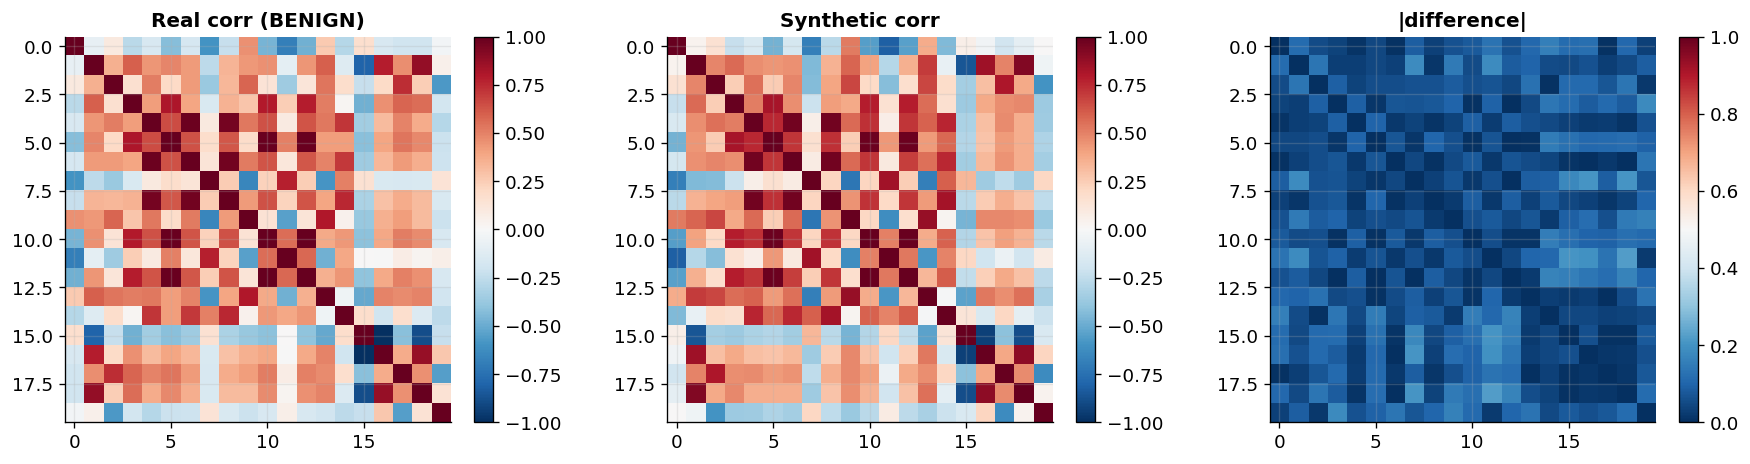

Mean absolute correlation error (BENIGN): 0.068


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


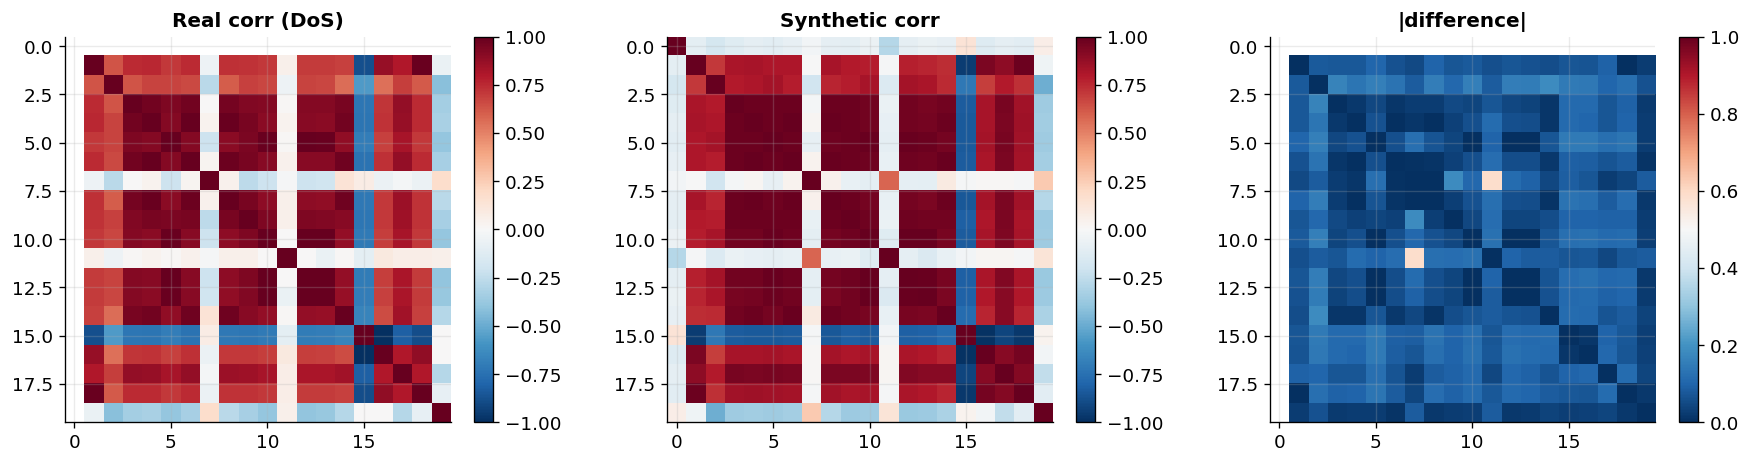

Mean absolute correlation error (DoS): nan


In [ ]:
# Correlation-structure check: does the generator reproduce feature dependencies?
def corr_error(real_c, fake_c, n_feats=20):
    R = np.corrcoef(real_c[:, :n_feats].T)
    Fk = np.corrcoef(fake_c[:, :n_feats].T)
    return R, Fk, np.abs(R - Fk)

# Correlation-structure check for BOTH classes (benign and DoS).
for cls in le.classes_:
    R, Fk, diff = corr_error(real_by_cls[cls], fake_by_cls[cls])
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for a, m, t in zip(ax, [R, Fk, diff],
                       [f"Real corr ({cls})", "Synthetic corr", "|difference|"]):
        im = a.imshow(m, vmin=(0 if "diff" in t else -1), vmax=1, cmap="RdBu_r")
        a.set_title(t); plt.colorbar(im, ax=a, fraction=.046)
    plt.tight_layout(); plt.show()
    print(f"Mean absolute correlation error ({cls}): {diff.mean():.3f}")